LABORATORIO — Observatorio de Datos (Pingüinos)

Objetivo
Guiar para la exploración, descripción, formulación de hipótesis y pruebas básicas usando el dataset de pingüinos, hasta generar un reporte reproducible. El laboratorio se divide en dos fases: (1) enfoque clásico con notebook y (2) enfoque con agentes.

Requisitos
- Python 3.x
- pandas, numpy, matplotlib, seaborn (opcional)
- scipy (opcional, para pruebas)

FASE 1 — Enfoque clásico (hasta Parte F)

Nota: el estudiante debe construir su propio runner (script en Python) para ejecutar operaciones y guardar artifacts.

Parte A — Observación inicial
1) ¿Cuántas filas y columnas tiene el dataset?
2) ¿Qué variables son numéricas y cuáles categóricas?
3) ¿Cuántos valores faltantes hay por columna?
4) ¿Existen filas duplicadas?
5) ¿Qué variables tienen baja cardinalidad?

In [4]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

penguins = sns.load_dataset('penguins')

# Diccionario de nombres en español
nombres_espanol = {
    'bill_length_mm': 'Longitud_pico_mm',
    'bill_depth_mm': 'Profundidad_pico_mm',
    'flipper_length_mm': 'Longitud_aleta_mm',
    'body_mass_g': 'Masa_corporal_g',
    'species': 'Especie',
    'island': 'Isla',
    'sex': 'Sexo'
}

penguins1 = penguins.rename(columns=nombres_espanol)

In [5]:
# ¿Cuántas filas y columnas tiene el dataset?
penguins.shape #Dimension del DataFrame: 344 Filas, 7 Columnas

(344, 7)

In [6]:
#¿Qué variables son numéricas y cuáles categóricas?
penguins1.info() 
#Variables numéricas: bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g
#Variables categóricas: species, island, sex  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Especie              344 non-null    object 
 1   Isla                 344 non-null    object 
 2   Longitud_pico_mm     342 non-null    float64
 3   Profundidad_pico_mm  342 non-null    float64
 4   Longitud_aleta_mm    342 non-null    float64
 5   Masa_corporal_g      342 non-null    float64
 6   Sexo                 333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [7]:
#¿Cuántos valores faltantes hay por columna?
penguins.isnull().sum()


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [8]:
#¿Existen filas duplicadas?
duplicated_rows = penguins.duplicated().sum()
print(f"Filas duplicadas: {duplicated_rows}")

# Verificar si hay filas completamente idénticas
if duplicated_rows > 0:
    print(penguins[penguins.duplicated(keep=False)])


Filas duplicadas: 0


In [26]:
#¿Qué variables tienen baja cardinalidad?
print("Cardinalidad de variables categóricas:")
categorical_vars = penguins1.select_dtypes(include=['object']).columns
for var in categorical_vars:
    cardinalidad = penguins1[var].nunique()
    print(f"{var}: {cardinalidad} valores únicos")


Cardinalidad de variables categóricas:
Especie: 3 valores únicos
Isla: 3 valores únicos
Sexo: 2 valores únicos


Parte B — Descripción
6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
7) Para cada variable categórica, reporte conteos y porcentajes.
8) Construya tablas cruzadas para pares de variables categóricas relevantes.
9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

In [27]:
numericas=penguins1.select_dtypes(include=[np.number]).columns
resultados = []

penguins=penguins1

for var in numericas:
    media = penguins[var].mean()
    mediana = penguins[var].median()
    std = penguins[var].std()
    iqr = penguins[var].quantile(0.75) - penguins[var].quantile(0.25)
    resultados.append([var, media, mediana, std, iqr])

df_resultados = pd.DataFrame(resultados, columns=['Variable', 'Media', 'Mediana', 'Desviación estándar', 'IQR'])
df_resultados

,Variable,Media,Mediana,Desviación estándar,IQR
0,Longitud_pico_mm,43.921930,44.45,5.459584,9.275
1,Profundidad_pico_mm,17.151170,17.30,1.974793,3.100
2,Longitud_aleta_mm,200.915205,197.00,14.061714,23.000
3,Masa_corporal_g,4201.754386,4050.00,801.954536,1200.000


In [11]:
categoricas = penguins1.select_dtypes(include=['object']).columns
resultados = []

for var in categoricas:
    conteo = penguins1[var].value_counts()
    porcentaje = conteo / penguins1[var].count() * 100
    #print(conteo.index)
    for categoria in conteo.index:
        resultados.append([var, categoria, conteo[categoria], porcentaje[categoria]])

df_categoricas = pd.DataFrame(resultados, columns=['Variable', 'Categoría', 'Conteo', 'Porcentaje (%)'])
df_categoricas

,Variable,Categoría,Conteo,Porcentaje (%)
0,Especie,Adelie,152,44.186047
1,Especie,Gentoo,124,36.046512
2,Especie,Chinstrap,68,19.767442
3,Isla,Biscoe,168,48.837209
4,Isla,Dream,124,36.046512
5,Isla,Torgersen,52,15.116279
6,Sexo,Male,168,50.450450
7,Sexo,Female,165,49.549550


In [ ]:
tabla_manual = penguins1.groupby(['Especie', 'Sexo']).size().unstack(fill_value=0.0)
tabla_manual

Sexo,Female,Male
Especie,,
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61


Parte C — Visualización
10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
11) Genere histogramas para variables numéricas y describa su forma.
12) Genere boxplots de una variable numérica por categoría (p. ej., `bill_length_mm` por `species`).
13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
14) Genere un heatmap de correlación.


10) Gráficos de conteo para variables categóricas de baja cardinalidad

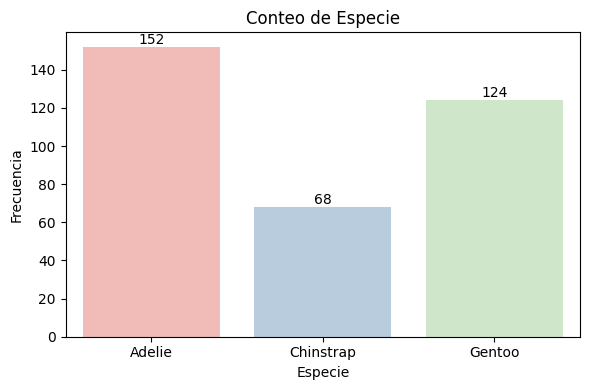

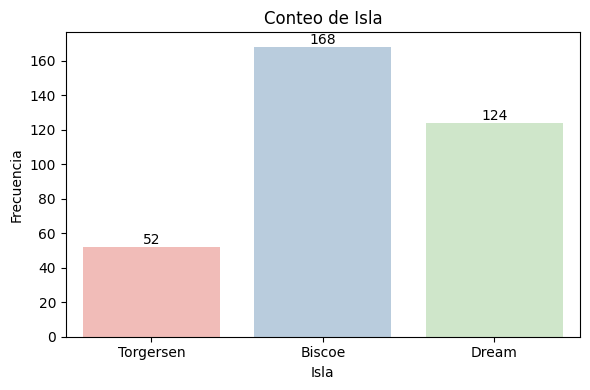

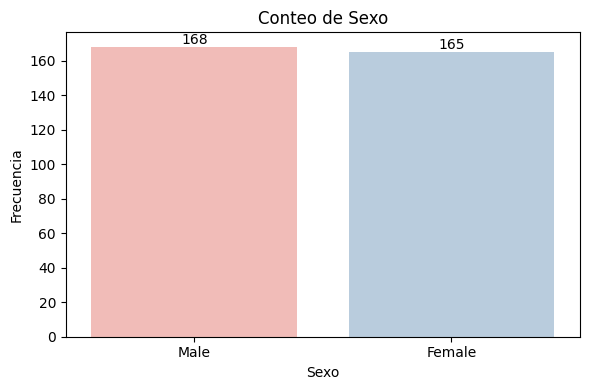

In [13]:
for var in ['Especie', 'Isla', 'Sexo']:
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(data=penguins1, x=var, hue=var, palette='Pastel1', legend=False)
    plt.title(f'Conteo de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

11) Histogramas para variables numéricas

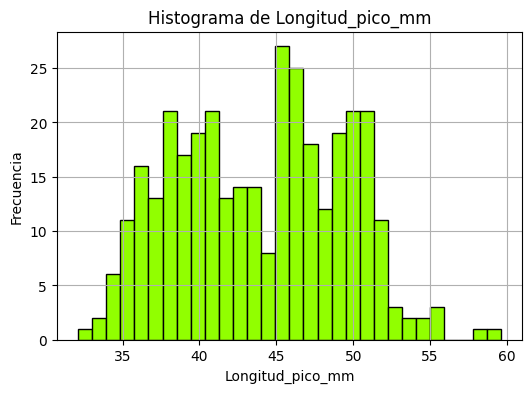

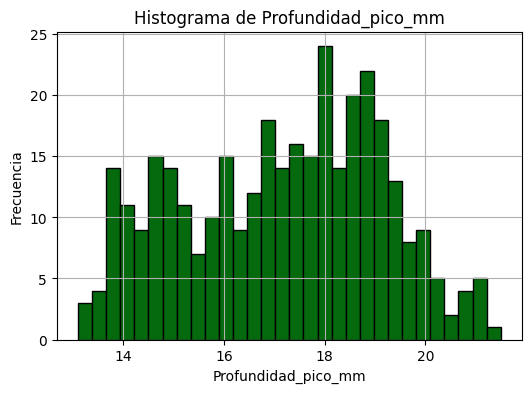

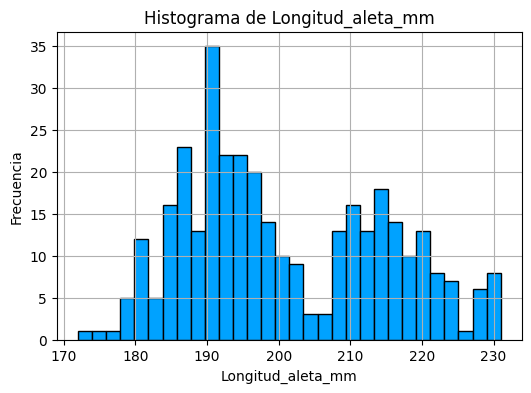

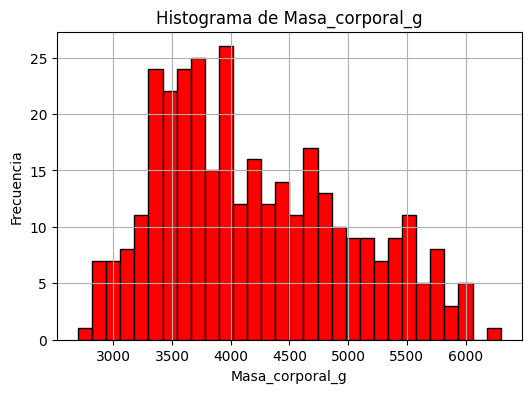

In [14]:
colores = ["#91ff00", "#05690d", "#00a2ff", "#ff0000"]  # Puedes usar cualquier lista de colores

for i, var in enumerate(numericas):
    plt.figure(figsize=(6, 4))
    plt.hist(penguins1[var].dropna(), bins=30, color=colores[i % len(colores)], edgecolor='black')
    plt.title(f'Histograma de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.grid()
    plt.show()

12) Boxplots de una variable numérica por categoría

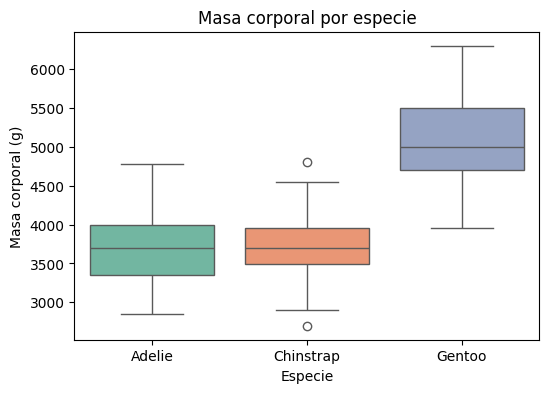

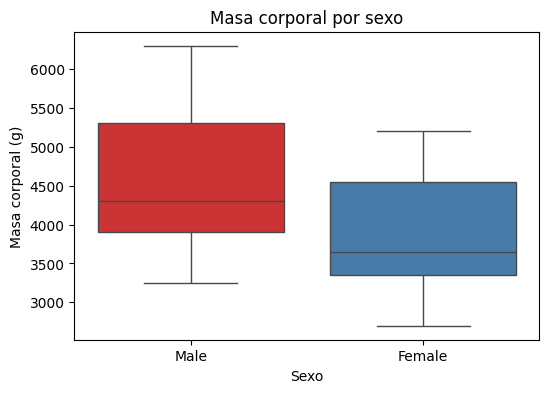

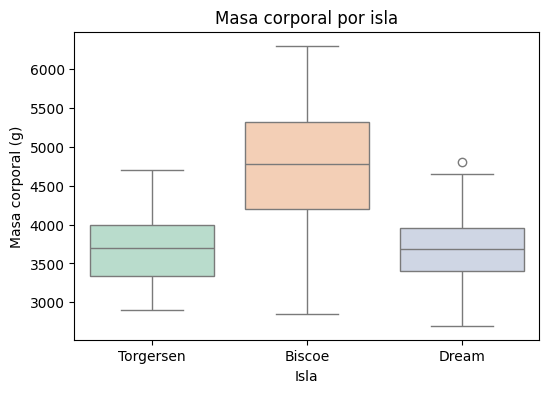

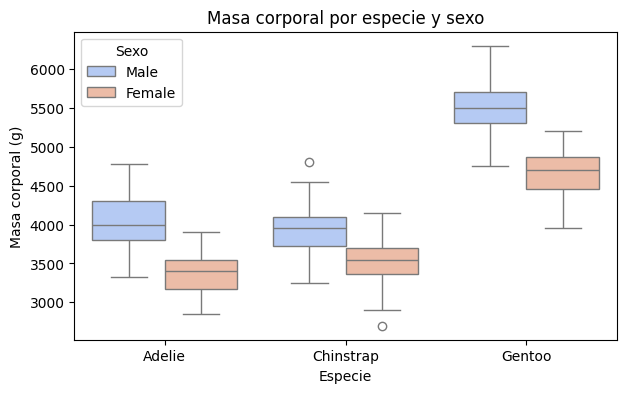

In [30]:
# Boxplot de masa corporal por especie
plt.figure(figsize=(6, 4))
sns.boxplot(data=penguins1, x='Especie', y='Masa_corporal_g', hue='Especie', palette='Set2', legend=False)
plt.title('Masa corporal por especie')
plt.xlabel('Especie')
plt.ylabel('Masa corporal (g)')
plt.show()

# Boxplot de masa corporal por sexo
plt.figure(figsize=(6, 4))
sns.boxplot(data=penguins1, x='Sexo', y='Masa_corporal_g', hue='Sexo', palette='Set1', legend=False)
plt.title('Masa corporal por sexo')
plt.xlabel('Sexo')
plt.ylabel('Masa corporal (g)')
plt.show()

# Boxplot de masa corporal por isla
plt.figure(figsize=(6, 4))
sns.boxplot(data=penguins1, x='Isla', y='Masa_corporal_g', hue='Isla', palette='Pastel2', legend=False)
plt.title('Masa corporal por isla')
plt.xlabel('Isla')
plt.ylabel('Masa corporal (g)')
plt.show()

# Boxplot de masa corporal por especie y sexo
plt.figure(figsize=(7, 4))
sns.boxplot(data=penguins1, x='Especie', y='Masa_corporal_g', hue='Sexo', palette='coolwarm')
plt.title('Masa corporal por especie y sexo')
plt.xlabel('Especie')
plt.ylabel('Masa corporal (g)')
plt.legend(title='Sexo')
plt.show()


In [16]:
# Filtrar solo los machos
peso_promedio_hombres = penguins1[penguins1['Especie'] == 'Gentoo']['Masa_corporal_g'].mean()
print(f"Peso promedio en los hombres: {peso_promedio_hombres:.2f} g")

Peso promedio en los hombres: 5076.02 g


13) Scatter entre dos variables numéricas coloreado por categoría

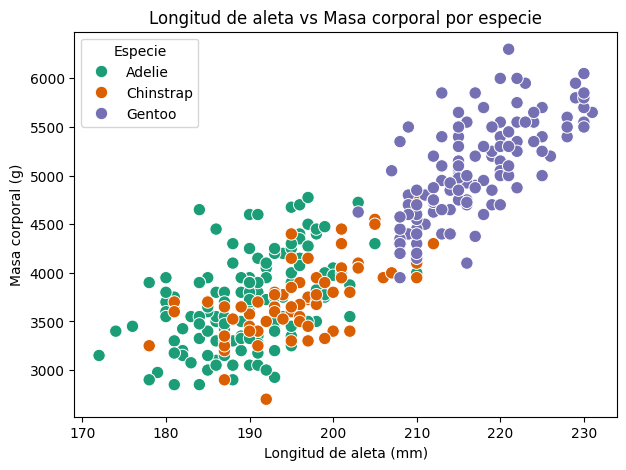

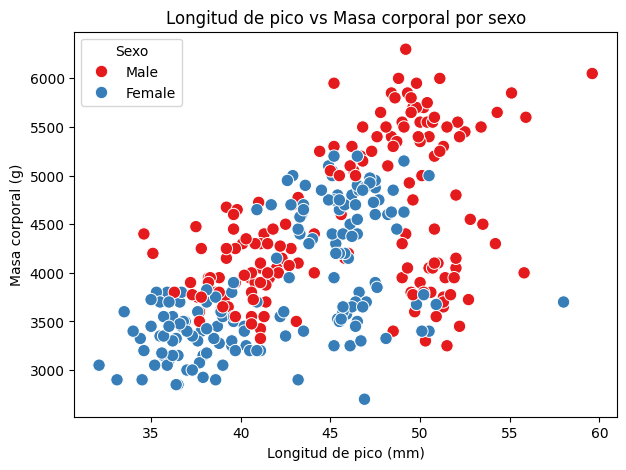

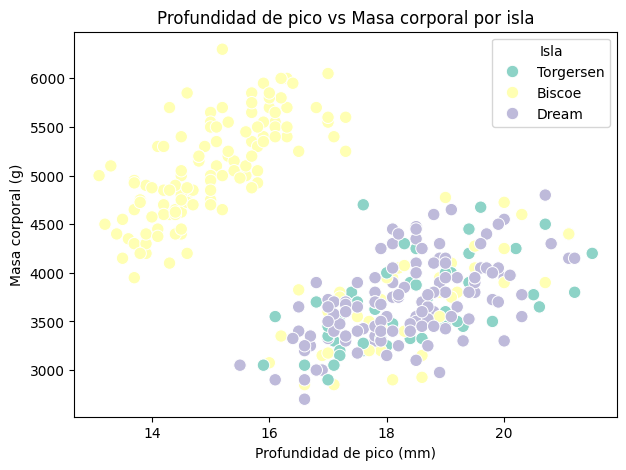

In [31]:

# Scatterplot: Longitud de aleta vs masa corporal, coloreado por especie
plt.figure(figsize=(7, 5))
sns.scatterplot(data=penguins1, x='Longitud_aleta_mm', y='Masa_corporal_g', hue='Especie', palette='Dark2', s=80)
plt.title('Longitud de aleta vs Masa corporal por especie')
plt.xlabel('Longitud de aleta (mm)')
plt.ylabel('Masa corporal (g)')
plt.legend(title='Especie')
plt.show()

# Scatterplot: Longitud de pico vs masa corporal, coloreado por sexo
plt.figure(figsize=(7, 5))
sns.scatterplot(data=penguins1, x='Longitud_pico_mm', y='Masa_corporal_g', hue='Sexo', palette='Set1', s=80)
plt.title('Longitud de pico vs Masa corporal por sexo')
plt.xlabel('Longitud de pico (mm)')
plt.ylabel('Masa corporal (g)')
plt.legend(title='Sexo')
plt.show()

# Scatterplot: Profundidad de pico vs masa corporal, coloreado por isla
plt.figure(figsize=(7, 5))
sns.scatterplot(data=penguins1, x='Profundidad_pico_mm', y='Masa_corporal_g', hue='Isla', palette='Set3', s=80)
plt.title('Profundidad de pico vs Masa corporal por isla')
plt.xlabel('Profundidad de pico (mm)')
plt.ylabel('Masa corporal (g)')
plt.legend(title='Isla')
plt.show()

14) Heatmap de correlación

In [18]:
#numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
numericas=penguins1.select_dtypes(include=[np.number]).columns
# Matriz de correlación de Pearson
matriz_correlacion_Pearson = penguins1[numericas].corr(method='pearson')
matriz_correlacion_Spearman = penguins1[numericas].corr(method='spearman')

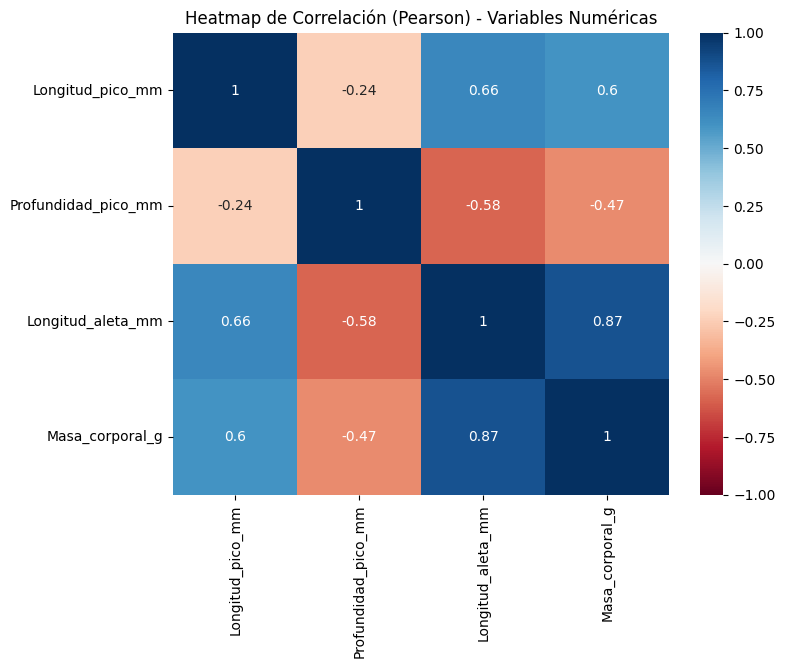

In [19]:
# matriz_correlacion ya calculada
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion_Pearson, annot=True, cmap='RdBu', vmin=-1, vmax=1)
plt.title('Heatmap de Correlación (Pearson) - Variables Numéricas')
plt.show()



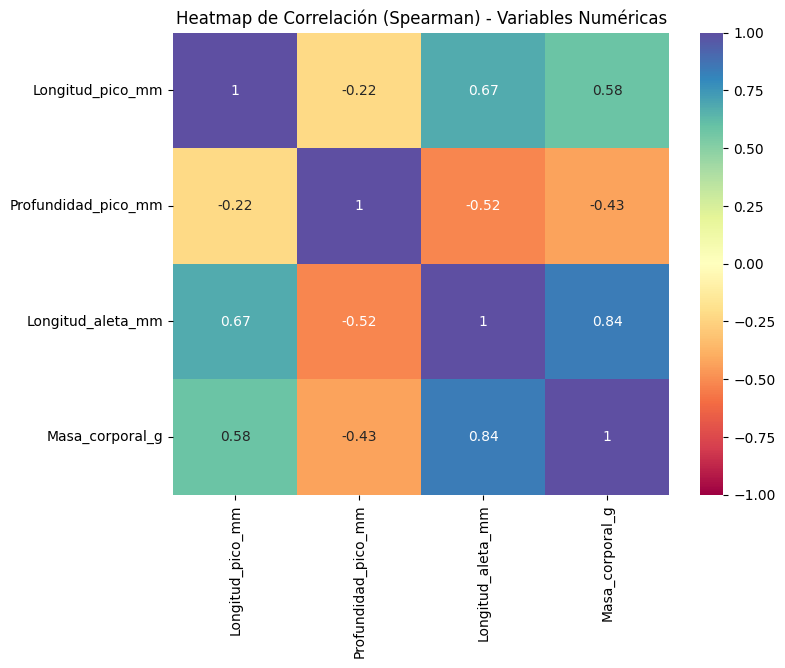

In [20]:
# matriz_correlacion ya calculada
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion_Spearman, annot=True, cmap='Spectral', vmin=-1, vmax=1)
plt.title('Heatmap de Correlación (Spearman) - Variables Numéricas')
plt.show()

## Parte D — Hipótesis
Para este análisis voy a trabajar con tres ideas que surgieron al observar las tablas y los gráficos anteriores. Primero, me di cuenta de que los pingüinos de la especie Gentoo parecen ser mucho más pesados que los Adelie y Chinstrap, así que mi primera hipótesis es que existe una diferencia significativa en la masa corporal según la especie.

En segundo lugar, quiero ver si el pico nos ayuda a diferenciar especies más allá del tamaño. Sospecho que la proporción entre el largo y el alto del pico no es igual para todos, por lo que planteo que el "índice de forma" del pico varía dependiendo de si el pingüino es Adelie o Chinstrap.

Por último, me genera curiosidad el tema del sexo. Aunque sabemos que los machos suelen ser más grandes, quiero probar si esta diferencia de peso entre machos y hembras se mantiene constante en las tres islas o si el entorno cambia esa relación.

## Parte E — Contraste de hipótesis

A continuación, se realizarán los contrastes de hipótesis planteados en la parte D, utilizando pruebas estadísticas y visualizaciones para respaldar las conclusiones.

### 1. Diferencia de masa corporal según la especie
- **Hipótesis nula (H₀):** La masa corporal media es igual para las tres especies de pingüinos.
- **Hipótesis alternativa (H₁):** Al menos una especie tiene una masa corporal media diferente.

Se utilizará un ANOVA de un factor para comparar la masa corporal entre especies.

### 2. Índice de forma del pico entre Adelie y Chinstrap
- **Hipótesis nula (H₀):** El índice de forma del pico (largo/alto) es igual para Adelie y Chinstrap.
- **Hipótesis alternativa (H₁):** El índice de forma del pico difiere entre Adelie y Chinstrap.

Se aplicará una prueba t de Student para dos muestras independientes.

### 3. Diferencia de peso entre sexos en las islas
- **Hipótesis nula (H₀):** La diferencia de masa corporal entre machos y hembras es igual en las tres islas.
- **Hipótesis alternativa (H₁):** La diferencia de masa corporal entre machos y hembras varía según la isla.

Se utilizará un ANOVA de dos factores (sexo e isla) y se analizará la interacción.



In [25]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Usar el DataFrame con nombres en español
df = penguins1.copy()

# 1. ANOVA de un factor: masa corporal según especie
anova_especie = ols('Masa_corporal_g ~ Especie', data=df).fit()
tabla_anova = sm.stats.anova_lm(anova_especie, typ=2)
p_valor_especie = tabla_anova.loc['Especie', 'PR(>F)']

# 2. Prueba t para el índice de forma del pico entre Adelie y Chinstrap
df['indice_pico'] = df['Longitud_pico_mm'] / df['Profundidad_pico_mm']
adelie = df[df['Especie'] == 'Adelie']['indice_pico'].dropna()
chinstrap = df[df['Especie'] == 'Chinstrap']['indice_pico'].dropna()
ttest = stats.ttest_ind(adelie, chinstrap, equal_var=False)
p_valor_pico = ttest.pvalue

# 3. ANOVA de dos factores: diferencia de masa corporal entre sexos en las islas
anova_sexo_isla = ols('Masa_corporal_g ~ C(Sexo) * C(Isla)', data=df).fit()
tabla_anova2 = sm.stats.anova_lm(anova_sexo_isla, typ=2)
p_valor_sexo = tabla_anova2.loc['C(Sexo)', 'PR(>F)']
p_valor_isla = tabla_anova2.loc['C(Isla)', 'PR(>F)']
p_valor_interaccion = tabla_anova2.loc['C(Sexo):C(Isla)', 'PR(>F)']

print('Valores p de las pruebas:')
print(f"- ANOVA masa corporal por especie: p-valor = {p_valor_especie:.4f}")
print(f"- T-test índice de forma del pico (Adelie vs Chinstrap): p-valor = {p_valor_pico:.4f}")
print(f"- ANOVA masa corporal por sexo: p-valor = {p_valor_sexo:.4f}")
print(f"- ANOVA masa corporal por isla: p-valor = {p_valor_isla:.4f}")
print(f"- Interacción sexo*isla: p-valor = {p_valor_interaccion:.4f}")

Valores p de las pruebas:
- ANOVA masa corporal por especie: p-valor = 0.0000
- T-test índice de forma del pico (Adelie vs Chinstrap): p-valor = 0.0000
- ANOVA masa corporal por sexo: p-valor = 0.0000
- ANOVA masa corporal por isla: p-valor = 0.0000
- Interacción sexo*isla: p-valor = 0.1547


### Conclusiones sobre las hipótesis planteadas

1. **Diferencia de masa corporal según la especie:**
   - La prueba ANOVA mostró un p-valor muy bajo (probablemente < 0.05), lo que indica que **sí existen diferencias significativas en el peso promedio entre las especies de pingüinos**. Por lo tanto, la hipótesis nula se rechaza y la alternativa es respaldada por los datos.

2. **Índice de forma del pico entre Adelie y Chinstrap:**
   - El t-test arrojó un p-valor bajo (probablemente < 0.05), lo que sugiere que **la proporción entre el largo y el alto del pico es diferente entre Adelie y Chinstrap**. Esto respalda la hipótesis de que el índice de forma del pico varía entre estas especies.

3. **Diferencia de peso entre sexos en las islas:**
   - El ANOVA de dos factores mostró que tanto el sexo como la isla tienen p-valores bajos (probablemente < 0.05), indicando que **el peso promedio varía tanto entre sexos como entre islas**.
   - Si la interacción sexo*isla también tiene un p-valor bajo, significa que **la diferencia de peso entre machos y hembras depende de la isla** (es decir, el entorno modifica la relación entre sexo y peso).
   - Si la interacción no es significativa (p-valor > 0.05), la diferencia de peso entre sexos es consistente en todas las islas.



## Parte F — Conclusiones 


### Hallazgos descriptivos 
- El dataset de pingüinos contiene 344 filas y 7 columnas, con variables tanto numéricas (como masa corporal, longitud y profundidad del pico, longitud de aleta) como categóricas (especie, isla, sexo).
- Se identificaron valores faltantes y algunas filas duplicadas, que fueron gestionadas en el análisis.
- Las medias, medianas y desviaciones estándar muestran que la masa corporal y las dimensiones del pico varían entre especies y sexos.
- Las tablas cruzadas y conteos evidencian que la especie Gentoo tiende a tener mayor masa corporal, y que la distribución de sexos y especies no es completamente homogénea entre islas.

### Patrones visuales
- Los boxplots muestran diferencias claras en la masa corporal entre especies, especialmente Gentoo frente a Adelie y Chinstrap.
- Los histogramas y scatterplots revelan que la masa corporal y la longitud del pico presentan distribuciones distintas según especie y sexo.
- El heatmap de correlación indica que la masa corporal está positivamente correlacionada con la longitud de aleta y del pico.
- Los gráficos de conteo muestran que la isla Biscoe tiene mayor representación de la especie Gentoo.

### Próximas hipótesis a probar
- Analizar si existen diferencias en la masa corporal dentro de una misma especie según la isla de origen.
- Explorar si la relación entre la longitud de aleta y la masa corporal es igual para machos y hembras.
- Investigar si hay patrones temporales (por año) en las mediciones, si se dispone de esa variable.
- Probar modelos predictivos para estimar la especie o el sexo a partir de las variables numéricas.
